In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("dataset_preprocessing_final.csv")
print("Jumlah data:", len(df))
df[["full_text", "normalized_text"]].head()

Saving dataset_preprocessing_final.csv to dataset_preprocessing_final.csv
Jumlah data: 4345


,full_text,normalized_text
0,"Selain jadi orang asik, kalau genre anda masok...",selain jadi orang seru kalau genre anda masoki...
1,@LexMarteg Emang pernah dibahas ?\n\nKayak nya...,memang pernah dibahas seperti nya langsung dip...
2,@DivHumas_Polri katanya efisiensi anggaran? ko...,katanya efisiensi anggaran kok pasang iklan pa...
3,@hida_suryo @grok @dialogg05 @PartaiSocmed Kar...,karena efisiensi anggaran jadi sampah koruptor...
4,[BERITA] | Efisiensi Anggaran Pendidikan: Anta...,berita efisiensi anggaran pendidikan antara pe...


In [ ]:
!git clone https://github.com/fajri91/InSet.git

Cloning into 'InSet'...
remote: Enumerating objects: 16, done.
remote: Total 16 (delta 0), reused 0 (delta 0), pack-reused 16 (from 1)
Receiving objects: 100% (16/16), 49.18 KiB | 1.64 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
import os
print(os.listdir("InSet"))

pos = pd.read_csv("InSet/positive.tsv", sep="\t")
neg = pd.read_csv("InSet/negative.tsv", sep="\t")

print("Kolom positif:", pos.columns.tolist(), "| jumlah:", len(pos))
print("Kolom negatif:", neg.columns.tolist(), "| jumlah:", len(neg))
pos.head()

['positive.tsv', 'negative.tsv', '.git', 'README.md']
Kolom positif: ['word', 'weight'] | jumlah: 3609
Kolom negatif: ['word', 'weight'] | jumlah: 6609


,word,weight
0,hai,3
1,merekam,2
2,ekstensif,3
3,paripurna,1
4,detail,2


In [ ]:
lexicon = dict(zip(pos["word"], pos["weight"]))
lexicon.update(dict(zip(neg["word"], neg["weight"])))
print("Total kata dalam lexicon:", len(lexicon))

Total kata dalam lexicon: 9074


In [ ]:
def hitung_skor(teks):
    if not isinstance(teks, str):
        return 0
    return sum(lexicon.get(kata, 0) for kata in teks.split())

def beri_label(skor):
    if skor > 0:
        return "positif"
    elif skor < 0:
        return "negatif"
    else:
        return "netral"

In [ ]:
df["skor"] = df["normalized_text"].apply(hitung_skor)
df["label"] = df["skor"].apply(beri_label)

df[["normalized_text", "skor", "label"]].head(10)

,normalized_text,skor,label
0,selain jadi orang seru kalau genre anda masoki...,-30,negatif
1,memang pernah dibahas seperti nya langsung dip...,-28,negatif
2,katanya efisiensi anggaran kok pasang iklan pa...,-5,negatif
3,karena efisiensi anggaran jadi sampah koruptor...,-18,negatif
4,berita efisiensi anggaran pendidikan antara pe...,-3,negatif
5,thr berkurang karena efisiensi anggaran,-6,negatif
6,summary lebaran tahun ini dulur dulur banyak y...,-30,negatif
7,efisiensi anggaran pemkot jogja tiadakan buka ...,-3,negatif
8,di sepertiga malam terakhir gweh selama malam ...,-42,negatif
9,sahira hotel paledang amp pakuan pamit manajem...,3,positif


In [ ]:
print(df["label"].value_counts())
print()
print((df["label"].value_counts(normalize=True) * 100).round(2))

label
negatif    3786
positif     423
netral      136
Name: count, dtype: int64

label
negatif    87.13
positif     9.74
netral      3.13
Name: proportion, dtype: float64


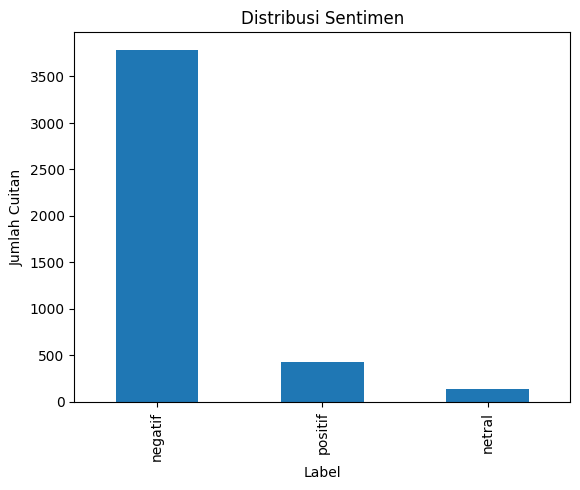

In [ ]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Distribusi Sentimen")
plt.xlabel("Label")
plt.ylabel("Jumlah Cuitan")
plt.show()

In [ ]:
df.to_csv("dataset_labeled.csv", index=False)
files.download("dataset_labeled.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sampel = df.sample(frac=0.10, random_state=42).copy()
sampel = sampel[["normalized_text", "label"]].rename(columns={"label": "label_otomatis"})
sampel["label_manual"] = ""
sampel.to_csv("sampel_validasi.csv", index=False)
files.download("sampel_validasi.csv")
print("Jumlah sampel validasi:", len(sampel))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Jumlah sampel validasi: 434


In [ ]:
uploaded = files.upload()
val = pd.read_excel("sampel_validasi.xlsx")

agreement = (val["label_otomatis"] == val["label_manual"]).mean() * 100
print("Agreement rate:", round(agreement, 2), "%")

Saving sampel_validasi.xlsx to sampel_validasi.xlsx
Agreement rate: 55.99 %


In [ ]:
val = pd.read_excel("sampel_validasi.xlsx")

# 1. cek isi kolom manual — ada sel kosong / beda tulisan?
print("== value_counts label_manual (termasuk kosong) ==")
print(val["label_manual"].value_counts(dropna=False))

# 2. samakan format: huruf kecil + buang spasi
val["label_otomatis"] = val["label_otomatis"].astype(str).str.strip().str.lower()
val["label_manual"]   = val["label_manual"].astype(str).str.strip().str.lower()

# 3. agreement setelah dibersihkan
agreement = (val["label_otomatis"] == val["label_manual"]).mean() * 100
print("\nAgreement rate (setelah dibersihkan):", round(agreement, 2), "%")

# 4. pola ketidaksesuaian: baris = label otomatis, kolom = label manual
print("\n== Crosstab otomatis vs manual ==")
print(pd.crosstab(val["label_otomatis"], val["label_manual"]))

== value_counts label_manual (termasuk kosong) ==
label_manual
negatif    218
netral     143
positif     73
Name: count, dtype: int64

Agreement rate (setelah dibersihkan): 55.99 %

== Crosstab otomatis vs manual ==
label_manual    negatif  netral  positif
label_otomatis                          
negatif             208     127       45
netral                3       9        2
positif               7       7       26


In [ ]:
!pip install Sastrawi -q
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from collections import Counter

stopwords = set(StopWordRemoverFactory().get_stop_words())

In [ ]:
def kata_teratas(label, n=10):
    teks = " ".join(df[df["label"] == label]["normalized_text"].astype(str))
    kata = [k for k in teks.split() if k not in stopwords and len(k) > 2]
    return Counter(kata).most_common(n)

for lab in ["positif", "netral", "negatif"]:
    print(f"\n=== Kata terbanyak kelas {lab.upper()} ===")
    for k, v in kata_teratas(lab, 10):
        print(f"{k}: {v}")


=== Kata terbanyak kelas POSITIF ===
anggaran: 399
efisiensi: 216
ribu: 118
pemerintah: 107
prabowo: 104
presiden: 103
pemangkasan: 83
triliun: 72
tahun: 65
menteri: 64

=== Kata terbanyak kelas NETRAL ===
anggaran: 125
efisiensi: 67
pemangkasan: 31
presiden: 22
pemerintah: 21
prabowo: 20
ribu: 19
apbn: 18
penghematan: 15
triliun: 15

=== Kata terbanyak kelas NEGATIF ===
anggaran: 3622
efisiensi: 1793
negara: 949
pemerintah: 910
apbn: 723
pemangkasan: 708
buat: 521
rakyat: 484
tahun: 477
kalau: 472


In [ ]:
for lab in ["positif", "netral", "negatif"]:
    print(f"\n=== Contoh cuitan kelas {lab.upper()} ===")
    for t in df[df["label"] == lab]["full_text"].head(3):
        print("-", t)


=== Contoh cuitan kelas POSITIF ===
- Sahira Hotel Paledang &amp; Pakuan Pamit, Manajemen: Terdampak Efisiensi Anggaran https://t.co/hSlZ3CkoBX
- Efisiensi Anggaran, IPB Batasi Penggunaan Listrik di Kampus

https://t.co/qdg9LB7dWT
- Banyu Biru Djarot Ajak Masyarakat Bersabar Akan Efisiensi Anggaran https://t.co/nuNcIXMR0p #pdiperjuangan

=== Contoh cuitan kelas NETRAL ===
- BNPB setelah efisiensi anggaran:
- AOWKWKWK EFISIENSI ANGGARAN KNTOL https://t.co/pg42dxN8U1
- @usousousoo Efisiensi anggaran 😂

=== Contoh cuitan kelas NEGATIF ===
- Selain jadi orang asik, kalau genre anda masokis, peganglah kerjaan2 vital organisasi (kerjaan yang ada hubungannya sama biro/divisi yg banyak anggaran) kalau anda penempatan UPT (Keuangan, monev organisasi, dll) biasanya (sebelum efisiensi) minim 3x perjadin
- @LexMarteg Emang pernah dibahas ?

Kayak nya langsung diputuskan dan disahkan deh tuh

Di hotel palingan refreshing doang sambil efisiensi anggaran biar nggak sisa banyak² dan tak jadi mubazir


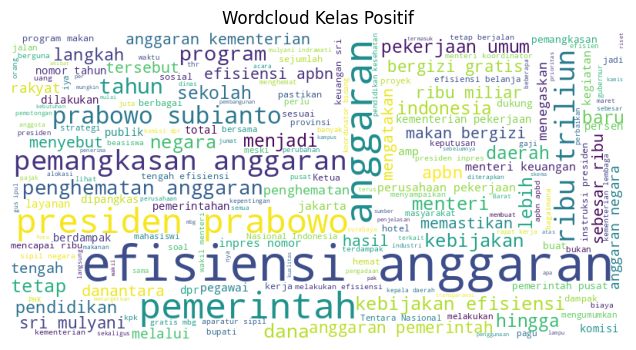

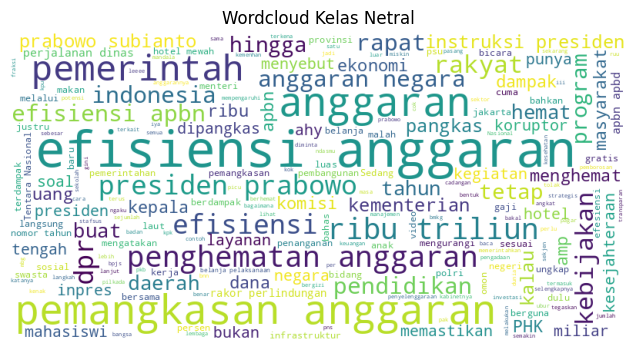

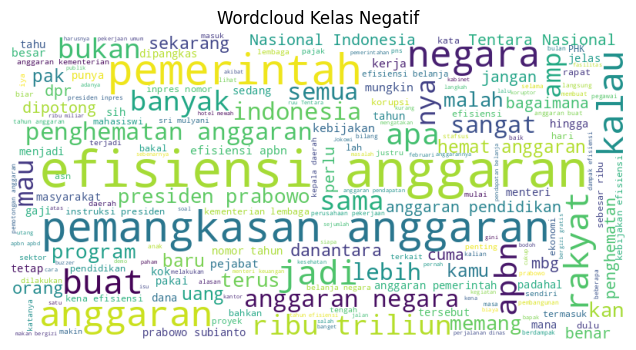

In [ ]:
!pip install wordcloud -q
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for lab in ["positif", "netral", "negatif"]:
    teks = " ".join(df[df["label"] == lab]["normalized_text"].astype(str))
    teks = " ".join(k for k in teks.split() if k not in stopwords and len(k) > 2)
    wc = WordCloud(width=800, height=400, background_color="white").generate(teks)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Wordcloud Kelas {lab.capitalize()}")
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df["normalized_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # jaga proporsi kelas di latih & uji
    random_state=42
)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji  :", len(X_test))

Jumlah data latih: 3476
Jumlah data uji  : 869


In [ ]:
print("=== Distribusi data latih ===")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True)*100).round(2))

print("\n=== Distribusi data uji ===")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True)*100).round(2))

=== Distribusi data latih ===
label
negatif    3029
positif     338
netral      109
Name: count, dtype: int64
label
negatif    87.14
positif     9.72
netral      3.14
Name: proportion, dtype: float64

=== Distribusi data uji ===
label
negatif    757
positif     85
netral      27
Name: count, dtype: int64
label
negatif    87.11
positif     9.78
netral      3.11
Name: proportion, dtype: float64


In [ ]:
train_df = pd.DataFrame({"normalized_text": X_train, "label": y_train})
test_df  = pd.DataFrame({"normalized_text": X_test,  "label": y_test})

train_df.to_csv("dataset_train.csv", index=False)
test_df.to_csv("dataset_test.csv", index=False)
files.download("dataset_train.csv")
files.download("dataset_test.csv")
print("Data latih & uji disimpan.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data latih & uji disimpan.
